# Evaluación 1 — Calidad y Preparación de Datos
## Rendimiento Académico Estudiantil

**Autores:**
* **Cristóbal Soto Vidal** - cristobal.soto2301@alumnos.ubiobio.cl
* **Martín Romero Álvarez** - martin.romero2301@alumnos.ubiobio.cl
* **Benjamín Paredes Aguayo** - benjamin.paredes2301@alumnos.ubiobio.cl
* **Darío Silva Pedreros** - dario.silva2301@alumnos.ubiobio.cl

**Asignatura:** Inteligencia Artificial (620454)

**Fecha:** Septiembre 2026

**Versión:** 1.0

---

## Descripción

Este notebook desarrolla el proceso completo de **diagnóstico de calidad, análisis exploratorio (EDA) y preparación de datos** para el dataset `rendimiento_academico_evaluacion.csv`, que contiene información demográfica, hábitos de estudio, antecedentes académicos y rendimiento final de un conjunto de estudiantes.

## Objetivo

Determinar si el dataset presenta problemas de calidad que puedan afectar conclusiones futuras, entender el comportamiento del rendimiento académico (`FinalGrade`) y construir un proceso **reproducible** (Pipeline + ColumnTransformer) que entregue un dataset final tratado, listo para análisis o modelado posterior.

## Contexto de negocio

Una institución de educación superior necesita comprender qué factores (asistencia, horas de estudio, beca, programa académico, etc.) se asocian al rendimiento final de sus estudiantes. Antes de construir cualquier modelo predictivo es indispensable auditar la calidad del dato: un modelo entrenado sobre datos sucios reproduce y amplifica el ruido en lugar de aprender patrones reales (**principio GIGO — Garbage In, Garbage Out**).

## Metadata del dataset

La siguiente tabla sigue el diccionario de datos oficial (`Metadata.md`) entregado por la docente para esta
evaluación, que define el rol, tipo y restricciones de dominio de cada variable.

| Variable | Tipo esperado | Descripción | Restricciones de dominio conocidas |
|---|---|---|---|
| `StudentID` | Texto (identificador) | Código único del estudiante | Formato `STU-#####`, no debería repetirse |
| `Age` | Numérica continua | Edad del estudiante | Positiva; rango plausible universitario |
| `StudyHours` | Numérica continua | Horas **semanales** dedicadas al estudio (según `Metadata.md`) | No negativa; máximo físico 168 h/semana (7 días × 24 h) |
| `Attendance` | Numérica continua | Porcentaje de asistencia a clases | Entre 0 y 100 (%) |
| `PreviousGPA` | Numérica continua | Promedio académico previo | Escala 1.0 a 10.0 (según `Metadata.md`) |
| `AssignmentsCompleted` | Numérica continua | % de tareas/asignaciones completadas | Entre 0 y 100 (%) |
| `SleepHours` | Numérica continua | Horas de sueño diarias | Entre 0 y 24 (horas de un día) |
| `InternetHours` | Numérica continua | Horas diarias de uso de internet | Entre 0 y 24 (horas de un día) |
| `Scholarship` | Categórica binaria | Posesión de beca | Solo dos categorías válidas: Sí / No |
| `Program` | Categórica nominal | Programa académico del estudiante | Catálogo cerrado de carreras |
| `FinalGrade` | Numérica continua (**objetivo**) | Nota final del estudiante | Escala 1.0 a 10.0 (según `Metadata.md`) |

# 1. Fuente de datos

In [1]:
# Descarga del dataset desde el repositorio del grupo.
# IMPORTANTE: reemplazar la URL por el enlace RAW del repositorio del equipo
# que aloja `rendimiento_academico_evaluacion.csv` (ver "Repositorio Único" en la guía de la asignatura).
!wget -q -N "https://raw.githubusercontent.com/BenjiParedes/Ev.1_IA/main/E1%20-%20EDA/rendimiento_academico_evaluacion.csv" -O rendimiento_academico_evaluacion.csv || echo "No fue posible descargar desde GitHub; se intentará usar el archivo local."

In [2]:
import os

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

RANDOM_STATE = 29
RUTA_DATOS = "rendimiento_academico_evaluacion.csv"

assert os.path.exists(RUTA_DATOS), "No se encontró el archivo CSV. Verifique la descarga con wget."

data_raw = pd.read_csv(RUTA_DATOS)
print(f"Dataset cargado correctamente: {data_raw.shape[0]} registros, {data_raw.shape[1]} variables.")
data_raw.head()

Dataset cargado correctamente: 5100 registros, 11 variables.


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


# 2. Diagnóstico de calidad de datos

## 2.1 Caracterización del dataset

Antes de cualquier tratamiento, describimos la estructura básica del dataset: dimensiones, tipos de dato y el rol de cada variable (identificador, features, variable objetivo).

In [3]:
def caracterizar_dataset(df: pd.DataFrame) -> None:
    """
    Presenta un resumen estructurado de la caracterización de un dataset.

    Parámetros
    ----------
    df: pd.DataFrame
        Set de datos a caracterizar.

    Retorna
    -------
    None
        Imprime en consola un resumen estructurado (no retorna objeto).
    """
    print(f"Cantidad de registros : {df.shape[0]}")
    print(f"Cantidad de variables : {df.shape[1]}")
    print("\nTipos de dato por variable:")
    print(df.dtypes)


caracterizar_dataset(data_raw)

Cantidad de registros : 5100
Cantidad de variables : 11

Tipos de dato por variable:
StudentID                object
Age                     float64
StudyHours              float64
Attendance              float64
PreviousGPA             float64
AssignmentsCompleted    float64
SleepHours              float64
InternetHours           float64
Scholarship              object
Program                  object
FinalGrade              float64
dtype: object


In [4]:
identificador = "StudentID"
variable_objetivo = "FinalGrade"

variables_numericas = [
    "Age", "StudyHours", "Attendance", "PreviousGPA",
    "AssignmentsCompleted", "SleepHours", "InternetHours",
]
variables_categoricas = ["Scholarship", "Program"]

print(f"Identificador único       : {identificador}")
print(f"Variable objetivo (target) : {variable_objetivo}")
print(f"Variables numéricas ({len(variables_numericas)}) : {variables_numericas}")
print(f"Variables categóricas ({len(variables_categoricas)}) : {variables_categoricas}")

print(f"\n¿StudentID es único? {data_raw[identificador].is_unique}")
print(f"Valores únicos de StudentID: {data_raw[identificador].nunique()} de {len(data_raw)} registros")

Identificador único       : StudentID
Variable objetivo (target) : FinalGrade
Variables numéricas (7) : ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours']
Variables categóricas (2) : ['Scholarship', 'Program']

¿StudentID es único? False
Valores únicos de StudentID: 5000 de 5100 registros


**Interpretación:** el dataset contiene 5.100 registros y 11 variables. `StudentID` es el identificador
(no es único a nivel de fila porque, como se verá en la sección 2.3, existen filas duplicadas exactas).
`FinalGrade` es la variable objetivo. Las 7 variables numéricas describen hábitos y antecedentes del
estudiante, mientras que `Scholarship` y `Program` son categóricas (una binaria y una nominal).

## 2.2 Valores faltantes

Calculamos la cantidad y el porcentaje de nulos por variable para decidir una estrategia de tratamiento.

In [5]:
def resumen_nulos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula la cantidad y el porcentaje de valores faltantes por columna.

    Parámetros
    ----------
    df: pd.DataFrame
        Set de datos a evaluar.

    Retorna
    -------
    pd.DataFrame
        Tabla con columnas `Nulos_Absolutos` y `Porcentaje_Nulos`, ordenada
        de mayor a menor porcentaje de nulos.
    """
    resumen = pd.DataFrame({
        "Nulos_Absolutos": df.isnull().sum(),
        "Porcentaje_Nulos": (df.isnull().sum() / len(df) * 100).round(2),
    })
    return resumen[resumen["Nulos_Absolutos"] > 0].sort_values("Porcentaje_Nulos", ascending=False)


resumen_nulos(data_raw)

,Nulos_Absolutos,Porcentaje_Nulos
Attendance,224,4.39
AssignmentsCompleted,216,4.24
StudyHours,181,3.55
InternetHours,176,3.45
PreviousGPA,162,3.18
SleepHours,122,2.39
Age,103,2.02
Scholarship,81,1.59
Program,70,1.37


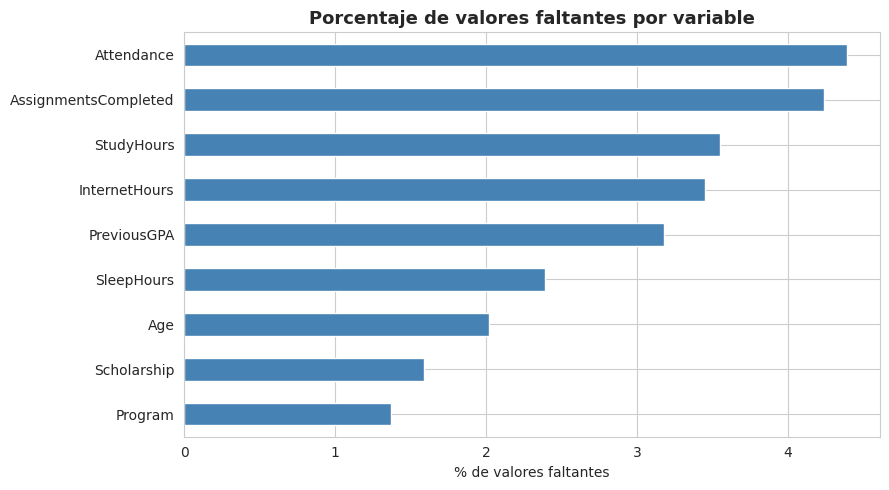

In [6]:
plt.figure(figsize=(9, 5))
resumen_nulos(data_raw)["Porcentaje_Nulos"].sort_values().plot(kind="barh", color="steelblue")
plt.title("Porcentaje de valores faltantes por variable", fontsize=13, fontweight="bold")
plt.xlabel("% de valores faltantes")
plt.tight_layout()
plt.show()

**Diagnóstico:** todas las variables predictoras (excepto `StudentID` y `FinalGrade`, que no presentan nulos)
tienen entre **1.37% y 4.39%** de valores faltantes. Ninguna variable supera el 5%, y no existe un patrón que
sugiera pérdida sistemática asociada a un subgrupo (los nulos aparecen distribuidos de forma similar entre
variables numéricas y categóricas), por lo que se asume un mecanismo cercano a **MCAR (Missing Completely
at Random)**.

**Estrategia y justificación:**
- **No se eliminan filas** con `dropna()`: como los nulos están distribuidos en distintas columnas, eliminar
  cualquier fila con al menos un nulo descartaría cerca de un 20% del dataset, perdiendo información valiosa
  y, potencialmente, sub-representando ciertos perfiles de estudiantes (ver discusión ética sobre filtrado
  ciego).
- **Variables numéricas:** se imputan con la **mediana**, medida robusta frente a los valores atípicos que se
  detectan más adelante (a diferencia de la media, no se ve arrastrada por outliers extremos).
- **Variables categóricas (`Scholarship`, `Program`):** se imputan con la **moda** (`most_frequent`), la
  estrategia estándar para variables nominales sin un orden natural.

Ambas imputaciones se implementan formalmente dentro del `Pipeline` de la sección 4, para que sean
reproducibles y se ajusten únicamente con la información disponible en cada ejecución.

## 2.3 Registros duplicados

Se evalúan dos niveles de duplicidad: duplicados **exactos** (misma información en todas las columnas) y
duplicados por **identificador** (`StudentID` repetido).

In [7]:
duplicados_totales = data_raw.duplicated(keep=False).sum()
duplicados_a_eliminar = data_raw.duplicated(keep="first").sum()
duplicados_por_id = data_raw.duplicated(subset=["StudentID"], keep="first").sum()

print(f"Filas involucradas en una duplicación exacta : {duplicados_totales}")
print(f"Filas duplicadas a eliminar (keep='first')    : {duplicados_a_eliminar} "
      f"({duplicados_a_eliminar/len(data_raw)*100:.2f}% del dataset)")
print(f"Duplicados por StudentID                      : {duplicados_por_id}")

data_raw[data_raw.duplicated(keep=False)].sort_values("StudentID").head(6)

Filas involucradas en una duplicación exacta : 200
Filas duplicadas a eliminar (keep='first')    : 100 (1.96% del dataset)
Duplicados por StudentID                      : 100


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
5017,STU-10014,24.0,21.21,91.56,5.67,97.82,6.37,10.60,No,Ingeniería Civil,4.87
4895,STU-10014,24.0,21.21,91.56,5.67,97.82,6.37,10.60,No,Ingeniería Civil,4.87
1437,STU-10028,21.0,12.94,80.47,5.96,NaN,7.47,5.39,No,Ingeniería Industrial,3.11
3572,STU-10028,21.0,12.94,80.47,5.96,NaN,7.47,5.39,No,Ingeniería Industrial,3.11
736,STU-10043,22.0,2.34,78.24,4.75,35.87,7.79,2.44,No,Administración,1.78
4829,STU-10043,22.0,2.34,78.24,4.75,35.87,7.79,2.44,No,Administración,1.78


**Diagnóstico:** existen **100 filas duplicadas exactas** (2.0% del dataset). Se comprueba que el número de
duplicados por `StudentID` coincide exactamente con el número de duplicados a nivel de fila completa: esto
confirma que se trata de **reingresos accidentales del mismo registro** (por ejemplo, un doble envío del
formulario o una concatenación de archivos con solapamiento), y no de dos estudiantes distintos que
comparten casualmente el mismo identificador con datos diferentes.

**Variable que identifica a un sujeto único:** `StudentID`.

**Decisión y justificación:** se eliminan los duplicados exactos conservando la **primera ocurrencia**
(`drop_duplicates(keep="first")`). Al ser copias idénticas del mismo estudiante, conservarlas no aporta
información nueva y sí introduce riesgo de **overfitting** (el modelo memorizaría ese registro en lugar de
aprender el patrón general), como se describe en el material de la asignatura.

## 2.4 Inconsistencias

Revisamos que cada variable respete las restricciones de su propio dominio (por ejemplo, un porcentaje no
puede ser negativo ni superar 100, y no pueden existir más de 24 horas en un día). También revisamos la
consistencia de **formato** en las variables categóricas.

In [8]:
def contar_violaciones_rango(df: pd.DataFrame, columna: str, minimo: float, maximo: float) -> pd.Series:
    """
    Identifica registros cuyo valor se encuentra fuera de un rango de dominio válido.

    Parámetros
    ----------
    df: pd.DataFrame
        Set de datos a evaluar.
    columna: str
        Nombre de la columna numérica a evaluar.
    minimo: float
        Límite inferior válido (inclusive) para la variable.
    maximo: float
        Límite superior válido (inclusive) para la variable.

    Retorna
    -------
    pd.Series
        Máscara booleana indicando qué registros violan el rango de dominio.
    """
    return (df[columna] < minimo) | (df[columna] > maximo)


# Reglas de dominio basadas en el diccionario de datos oficial (`Metadata.md`):
# - `StudyHours` es una variable semanal, por lo que su límite físico es 168 horas (24 h x 7 días).
# - `PreviousGPA` y `FinalGrade` se miden en una escala de 1.0 a 10.0.
reglas_dominio = {
    "Attendance": (0, 100),        # porcentaje de asistencia
    "SleepHours": (0, 24),         # horas dentro de un día
    "StudyHours": (0, 168),        # horas semanales (máximo físico: 24h x 7 días)
    "InternetHours": (0, 24),      # horas dentro de un día
    "PreviousGPA": (1.0, 10.0),    # escala oficial de notas (antecedente académico)
    "FinalGrade": (1.0, 10.0),     # escala oficial de notas (variable objetivo)
}

print("=== Inconsistencias de rango numérico ===")
resumen_inconsistencias = {}
for columna, (minimo, maximo) in reglas_dominio.items():
    mask = contar_violaciones_rango(data_raw, columna, minimo, maximo)
    resumen_inconsistencias[columna] = int(mask.sum())
    print(f"{columna:20s}: {mask.sum():4d} registros fuera de [{minimo}, {maximo}] "
          f"({mask.sum()/len(data_raw)*100:.2f}%)")


=== Inconsistencias de rango numérico ===
Attendance          :   20 registros fuera de [0, 100] (0.39%)
SleepHours          :    8 registros fuera de [0, 24] (0.16%)
StudyHours          :    0 registros fuera de [0, 168] (0.00%)
InternetHours       :   31 registros fuera de [0, 24] (0.61%)
PreviousGPA         :    0 registros fuera de [1.0, 10.0] (0.00%)
FinalGrade          :    4 registros fuera de [1.0, 10.0] (0.08%)


In [9]:
print("=== Inconsistencias de formato en variables categóricas ===")
print("\nScholarship — categorías crudas encontradas:")
print(data_raw["Scholarship"].value_counts(dropna=False))

print("\nProgram — categorías crudas encontradas:")
print(data_raw["Program"].value_counts(dropna=False))

n_categorias_scholarship_extra = data_raw["Scholarship"].dropna().str.strip().str.lower().nunique() - 1
n_categorias_program_extra = data_raw["Program"].dropna().str.strip().str.lower().nunique() \
    - data_raw["Program"].dropna().apply(
        lambda x: x.strip().lower().replace("í", "i").replace("ó", "o")
    ).nunique() + data_raw["Program"].dropna().apply(
        lambda x: x.strip().lower().replace("í", "i").replace("ó", "o")
    ).nunique()
print(f"\nScholarship: {data_raw['Scholarship'].dropna().nunique()} categorías crudas, deberían ser 2 (Sí/No).")
print(f"Program: {data_raw['Program'].dropna().nunique()} categorías crudas, deberían ser 5 programas.")

# --- Cantidad EXACTA de registros afectados (no solo cantidad de categorías) ---
# Se define el catálogo canónico (válido) de cada variable categórica y se cuentan,
# a nivel de REGISTRO, cuántas filas no calzan exactamente con alguna categoría válida
# (dejando fuera los nulos, que ya fueron cuantificados en la sección 2.2).
categorias_validas_scholarship = {"Sí", "No"}
categorias_validas_program = {
    "Ingeniería Informática",
    "Ingeniería Industrial",
    "Ingeniería Civil",
    "Administración",
    "Contador Auditor",
}

mask_formato_invalido_scholarship = data_raw["Scholarship"].dropna().apply(
    lambda x: x not in categorias_validas_scholarship
)
mask_formato_invalido_program = data_raw["Program"].dropna().apply(
    lambda x: x not in categorias_validas_program
)

n_formato_invalido_scholarship = int(mask_formato_invalido_scholarship.sum())
n_formato_invalido_program = int(mask_formato_invalido_program.sum())

print("\n=== Cantidad de registros con formato inválido/no canónico ===")
print(f"Scholarship: {n_formato_invalido_scholarship} registros "
      f"({n_formato_invalido_scholarship/len(data_raw)*100:.2f}% del dataset)")
print(f"Program    : {n_formato_invalido_program} registros "
      f"({n_formato_invalido_program/len(data_raw)*100:.2f}% del dataset)")

# Se incorporan al mismo resumen que las inconsistencias numéricas (sección 2.4, celda anterior),
# para que la comparación final (sección 6.3) contabilice el total real de inconsistencias tratadas
# y no solo las de dominio numérico.
resumen_inconsistencias["Scholarship_formato"] = n_formato_invalido_scholarship
resumen_inconsistencias["Program_formato"] = n_formato_invalido_program

=== Inconsistencias de formato en variables categóricas ===

Scholarship — categorías crudas encontradas:
Scholarship
No     3364
Sí     1620
NaN      81
si       10
No       10
NO        8
SÍ        5
SI        2
Name: count, dtype: int64

Program — categorías crudas encontradas:
Program
Ingeniería Informática     1424
Ingeniería Industrial      1119
Ingeniería Civil           1004
Administración              787
Contador Auditor            660
NaN                          70
Ingenieria Informatica       10
INGENIERÍA INFORMÁTICA        7
Ingeniería Civil              5
INGENIERÍA CIVIL              4
Ingeniería informática        4
ADMINISTRACIÓN                3
Administracion                3
Name: count, dtype: int64

Scholarship: 7 categorías crudas, deberían ser 2 (Sí/No).
Program: 12 categorías crudas, deberían ser 5 programas.

=== Cantidad de registros con formato inválido/no canónico ===
Scholarship: 35 registros (0.69% del dataset)
Program    : 36 registros (0.71% del datas

**Diagnóstico y tratamiento propuesto:**

| Variable | Problema detectado | Cantidad | Estrategia propuesta |
|---|---|---|---|
| `Attendance` | Valores fuera de `[0, 100]%` (negativos o superiores a 100) | 20 registros (0.39%) | Físicamente imposible → se marca como **inválido** (`NaN`) y se imputa con la mediana |
| `SleepHours` | Valores negativos (no se puede dormir un número negativo de horas) | 8 registros (0.16%) | Inválido → `NaN` + imputación con mediana |
| `StudyHours` | Se verifica contra su dominio semanal `[0, 168]` horas (`Metadata.md`) | 0 registros (0.00%) | Sin violaciones; no requiere invalidación de dominio (solo se tratarán sus outliers estadísticos en la sección 2.5) |
| `InternetHours` | Valores muy por sobre 24 horas en un día (hasta ~69 h) | 31 registros (0.61%) | Inválido → `NaN` + imputación con mediana |
| `FinalGrade` (objetivo) | Valores fuera de la escala `[1.0, 10.0]` | 4 registros (0.08%) | Se trata de la **etiqueta objetivo**: imputarla introduciría sesgo circular. Al ser una proporción marginal (<0.1%), se opta por **eliminar esas filas** del análisis |
| `Scholarship` | 7 variantes de texto para solo 2 categorías reales (`Sí`, `SÍ `, `sí`, `SI`, `No`, `NO`, `No `) | 35 registros (0.69%) | Normalizar a `{"Sí", "No"}` (quitar espacios, unificar mayúsculas/tildes) |
| `Program` | 12 variantes de texto para solo 5 programas reales (variaciones de mayúsculas, tildes y espacios) | 36 registros (0.71%) | Normalizar a un catálogo cerrado de 5 programas |

Para `Attendance`, `SleepHours` e `InternetHours` se decide **no eliminar directamente los registros**: el
resto de las variables del mismo estudiante (asistencia, notas previas, etc.) sigue siendo información válida
y útil, por lo que se prefiere invalidar únicamente el valor puntual imposible y luego imputarlo, en vez de
descartar todo el registro. `StudyHours` no requiere este tratamiento: al ser una variable semanal
(`Metadata.md`), su límite físico real es 168 horas y no presenta valores fuera de dominio.

Para `FinalGrade` sí se eliminan las filas, porque es la variable objetivo del posible modelo predictivo:
imputar una etiqueta con la mediana o la moda equivaldría a inventar el resultado que se busca predecir,
lo cual introduce una fuga de información artificial. Al representar menos de un 0.1% del dataset, la
pérdida de información es mínima.

## 2.5 Valores atípicos (outliers)

Aplicamos el **método del Rango Intercuartílico (IQR)** sobre las variables numéricas para detectar valores
estadísticamente atípicos, y los distinguimos de los valores **inválidos** ya identificados en la sección 2.4
(que violan una restricción física/de dominio y no simplemente la distribución estadística).

In [10]:
def diagnostico_outliers_iqr(df: pd.DataFrame, columna: str, factor: float = 1.5) -> dict:
    """
    Calcula los límites del método IQR y cuantifica los valores atípicos de una variable.

    Parámetros
    ----------
    df: pd.DataFrame
        Set de datos a analizar.
    columna: str
        Nombre de la columna numérica a analizar.
    factor: float
        Multiplicador del IQR utilizado para definir los límites (por defecto 1.5).

    Retorna
    -------
    dict
        Diccionario con los límites calculados y la cantidad/porcentaje de outliers detectados.
    """
    serie = df[columna].dropna()
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - factor * iqr
    limite_superior = q3 + factor * iqr
    mask = (serie < limite_inferior) | (serie > limite_superior)
    return {
        "variable": columna,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "n_outliers": int(mask.sum()),
        "pct_outliers": round(mask.sum() / len(serie) * 100, 2),
    }


resumen_outliers = pd.DataFrame([diagnostico_outliers_iqr(data_raw, col) for col in variables_numericas + ["FinalGrade"]])
resumen_outliers

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
0,Age,21.00,26.00,5.00,13.50,33.50,63,1.26
1,StudyHours,8.75,15.44,6.69,-1.28,25.48,49,1.00
2,Attendance,77.58,93.01,15.43,54.43,116.16,27,0.55
3,PreviousGPA,5.22,6.23,1.01,3.70,7.75,21,0.43
4,AssignmentsCompleted,75.85,100.00,24.15,39.62,136.23,17,0.35
5,SleepHours,6.16,7.86,1.70,3.61,10.41,34,0.68
6,InternetHours,3.80,8.39,4.59,-3.09,15.28,145,2.94
7,FinalGrade,3.51,4.86,1.35,1.48,6.89,37,0.73


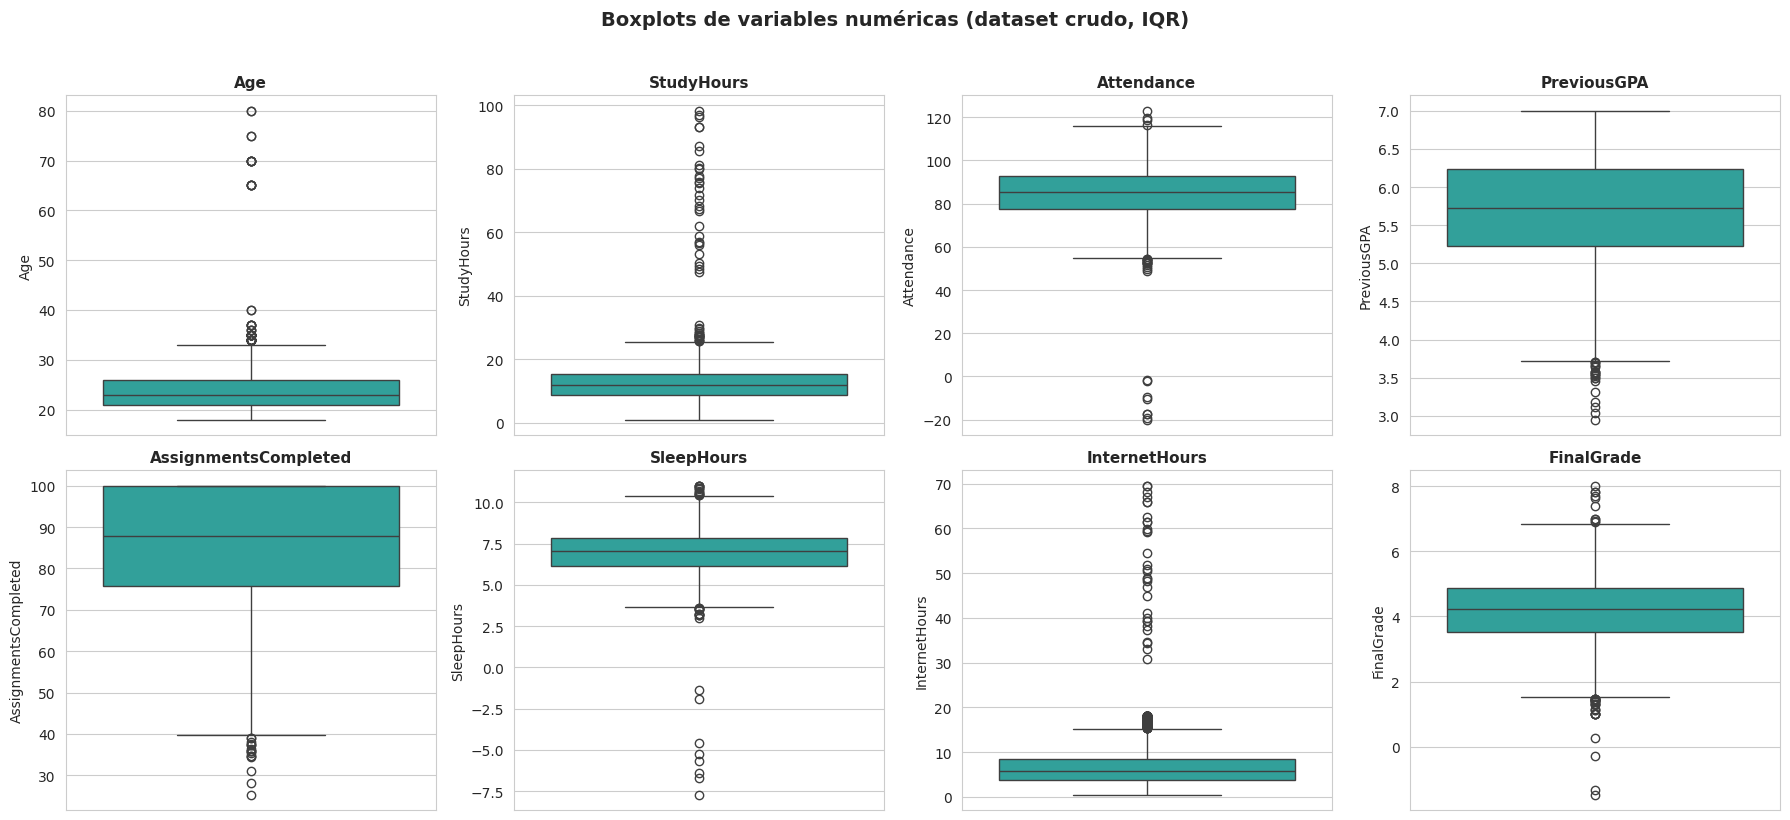

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), variables_numericas + ["FinalGrade"]):
    sns.boxplot(y=data_raw[col], ax=ax, color="lightseagreen")
    ax.set_title(col, fontsize=11, fontweight="bold")
fig.suptitle("Boxplots de variables numéricas (dataset crudo, IQR)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** varias de las cifras de la tabla anterior están infladas por los mismos valores
**inválidos** de la sección 2.4 (p. ej. los 4 valores de `FinalGrade` fuera de la escala oficial `[1.0, 10.0]`
dominan sus propios límites). Esto es esperable: un valor físicamente imposible también es, casi siempre, un
valor estadísticamente extremo. Por eso el tratamiento de dominio (2.4) debe aplicarse **antes** del
tratamiento de outliers para no confundir ambos fenómenos.

Descontando esas inconsistencias ya tratadas, quedan outliers **genuinos y plausibles**, por ejemplo:

- **`Age`**: estudiantes de 65 a 80 años son estadísticamente atípicos (la mayoría tiene entre 18 y 33 años),
  pero son perfectamente **posibles** (estudiantes que retoman sus estudios). No son un error de captura.
- **`StudyHours`**: los 49 registros que superan el límite superior de Li/Ls (hasta ~98 horas **semanales**)
  no son errores de captura, sino estudiantes con una carga de estudio semanal excepcionalmente alta —posible
  una vez que se interpreta correctamente la variable como semanal y no diaria (`Metadata.md`).
- **`FinalGrade`** (dentro de la escala oficial válida 1.0–10.0): notas muy bajas o muy altas son extremos
  legítimos del rendimiento académico real, no errores.
- **`InternetHours`** y **`AssignmentsCompleted`**: dentro del rango físicamente válido, algunos estudiantes
  presentan hábitos de uso o cumplimiento muy por encima/debajo del resto del curso, lo cual es un
  comportamiento real, no un error.

**Estrategia de tratamiento:** siguiendo el principio de auditoría e-EDA (no todo outlier es un error;
eliminarlos sistemáticamente puede borrar del dataset a estudiantes con perfiles minoritarios pero reales,
como los de mayor edad o los de rendimiento excepcional), se opta por **capar (winsorizar)** los valores
atípicos genuinos a los límites de Li/Ls del método IQR, en lugar de eliminarlos. Así se reduce su influencia
desproporcionada sobre medias y modelos lineales, **sin perder al estudiante ni su información en las demás
variables**. Este capping se aplica únicamente a las variables predictoras (no a `FinalGrade`, que se
mantiene intacta por ser la variable objetivo).

# 3. Análisis exploratorio de datos (EDA)

Para el EDA visual trabajamos sobre una copia auxiliar (`data_eda`) en la que únicamente se corrigen los
valores inválidos de dominio (para no distorsionar los gráficos con valores imposibles como -20% de
asistencia), sin todavía imputar ni capar outliers ni normalizar categorías — esas transformaciones formales
se reservan para el `Pipeline` de la sección 4.

In [12]:
data_eda = data_raw.copy()
for columna, (minimo, maximo) in reglas_dominio.items():
    if columna == "FinalGrade":
        continue  # el target inválido se filtra, no se convierte en NaN
    mask = contar_violaciones_rango(data_eda, columna, minimo, maximo)
    data_eda.loc[mask, columna] = np.nan

data_eda = data_eda[(data_eda["FinalGrade"] >= 1.0) & (data_eda["FinalGrade"] <= 10.0)].copy()

# Normalización ligera de texto solo para fines de visualización
def _normalizar_texto(valor: str) -> str:
    if pd.isna(valor):
        return valor
    limpio = str(valor).strip().lower()
    for a, b in [("í", "i"), ("á", "a"), ("ó", "o"), ("é", "e"), ("ú", "u")]:
        limpio = limpio.replace(a, b)
    mapa = {
        "si": "Sí", "no": "No",
        "ingenieria informatica": "Ingeniería Informática",
        "ingenieria industrial": "Ingeniería Industrial",
        "ingenieria civil": "Ingeniería Civil",
        "administracion": "Administración",
        "contador auditor": "Contador Auditor",
    }
    return mapa.get(limpio, str(valor).strip())

data_eda["Scholarship"] = data_eda["Scholarship"].apply(_normalizar_texto)
data_eda["Program"] = data_eda["Program"].apply(_normalizar_texto)

print(f"Dataset auxiliar para EDA: {data_eda.shape[0]} registros (tras filtrar FinalGrade inválido).")

Dataset auxiliar para EDA: 5096 registros (tras filtrar FinalGrade inválido).


### 3.1 Distribución de variables numéricas

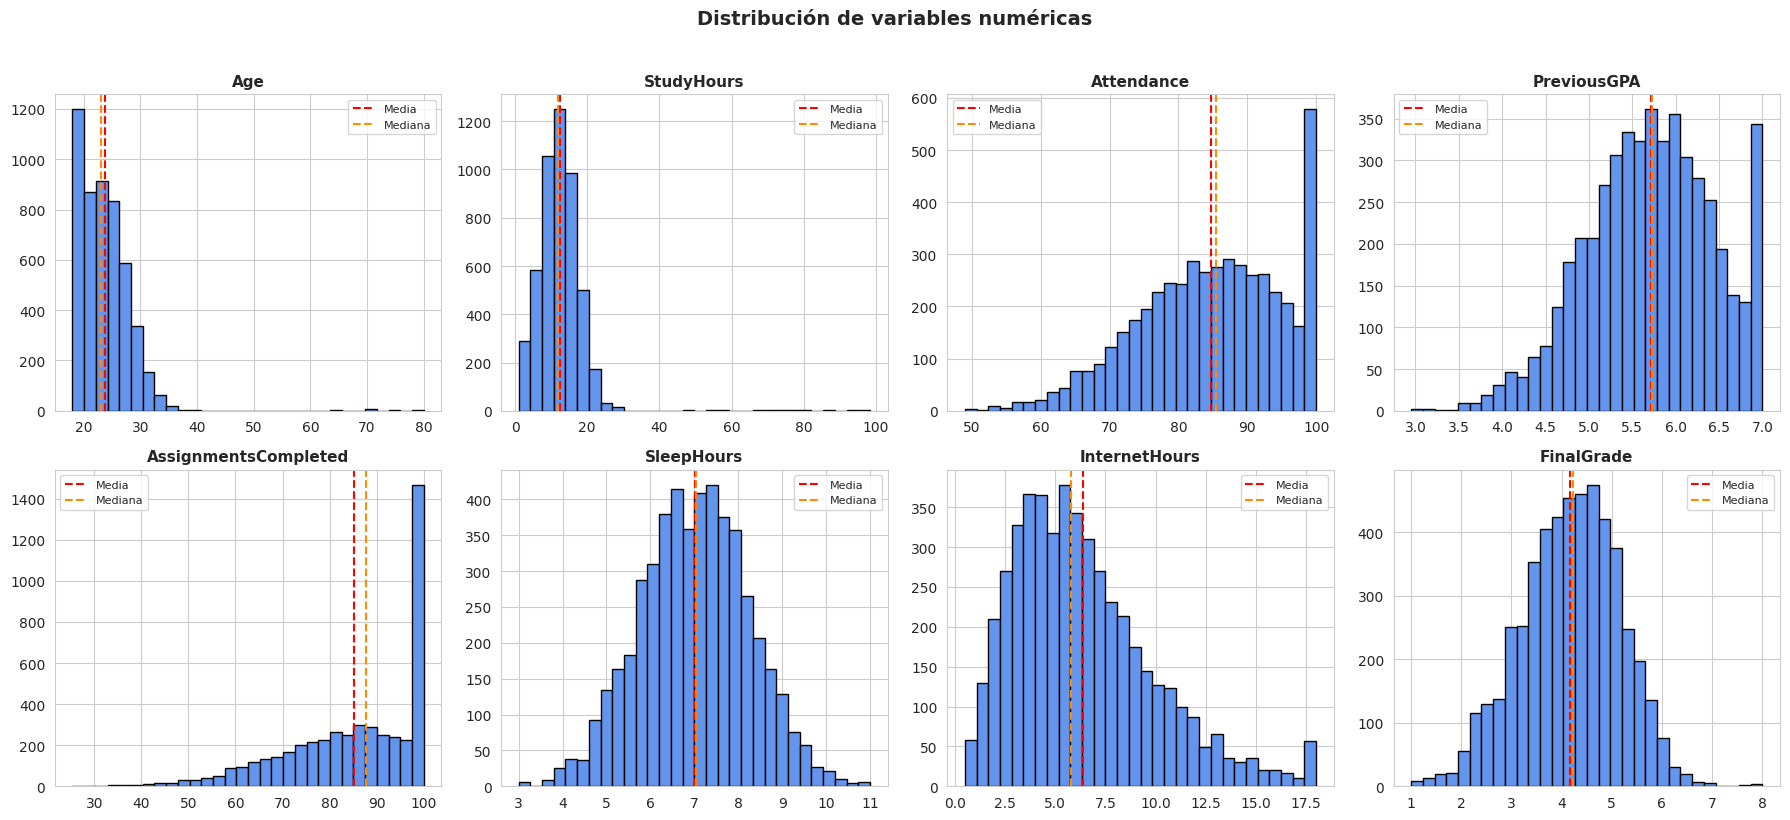

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), variables_numericas + ["FinalGrade"]):
    ax.hist(data_eda[col].dropna(), bins=30, color="cornflowerblue", edgecolor="black")
    ax.axvline(data_eda[col].mean(), color="red", linestyle="--", linewidth=1.5, label="Media")
    ax.axvline(data_eda[col].median(), color="darkorange", linestyle="--", linewidth=1.5, label="Mediana")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
fig.suptitle("Distribución de variables numéricas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** `Age` presenta una fuerte asimetría positiva (la mayoría de los estudiantes tiene entre
18 y 30 años, con una cola larga de estudiantes mayores). `StudyHours`, `Attendance`, `PreviousGPA` y
`FinalGrade` muestran formas razonablemente simétricas, cercanas a una campana, lo que favorece el uso de la
media/desviación estándar como resumen. `AssignmentsCompleted` está acumulado cerca del 100%, y
`InternetHours` muestra asimetría positiva con una cola de usuarios de alto consumo.

### 3.2 Comportamiento de variables categóricas

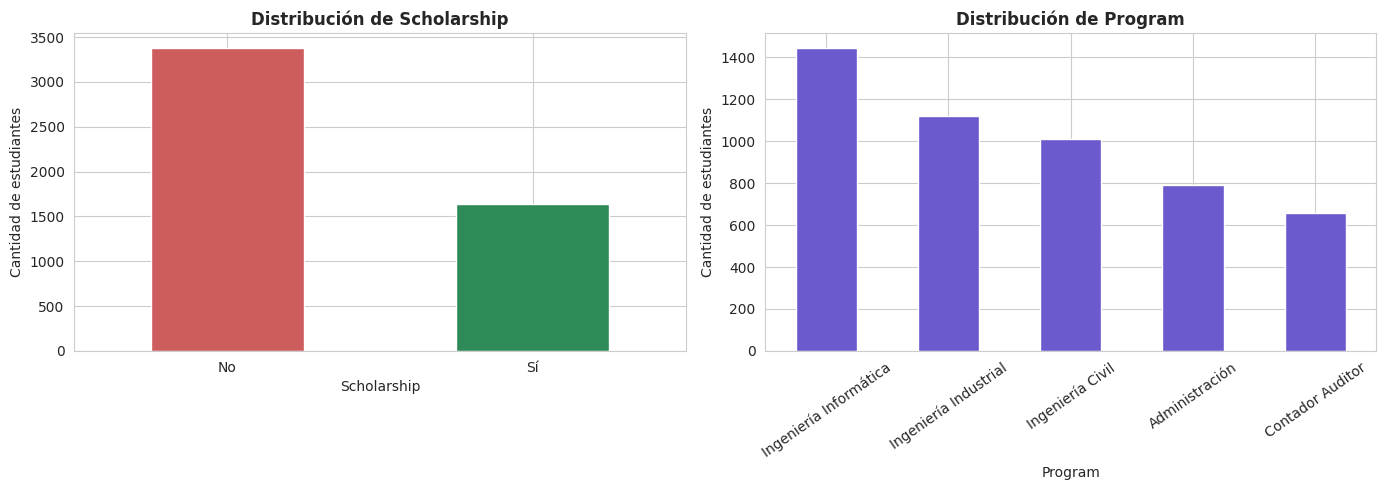

Scholarship
No    67.4
Sí    32.6
Name: proportion, dtype: float64

Program
Ingeniería Informática    28.8
Ingeniería Industrial     22.3
Ingeniería Civil          20.1
Administración            15.7
Contador Auditor          13.1
Name: proportion, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_eda["Scholarship"].value_counts().plot(kind="bar", ax=axes[0], color=["indianred", "seagreen"])
axes[0].set_title("Distribución de Scholarship", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Cantidad de estudiantes")
axes[0].tick_params(axis="x", rotation=0)

data_eda["Program"].value_counts().plot(kind="bar", ax=axes[1], color="slateblue")
axes[1].set_title("Distribución de Program", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Cantidad de estudiantes")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

print(data_eda["Scholarship"].value_counts(normalize=True).round(3) * 100)
print()
print(data_eda["Program"].value_counts(normalize=True).round(3) * 100)

**Interpretación:** cerca de dos tercios de los estudiantes no poseen beca (`No`) y un tercio sí (`Sí`).
`Ingeniería Informática` es el programa con más estudiantes, seguido de `Ingeniería Industrial` e
`Ingeniería Civil`; `Contador Auditor` es el programa con menor matrícula en este dataset.

### 3.3 Distribución de la variable objetivo (`FinalGrade`)

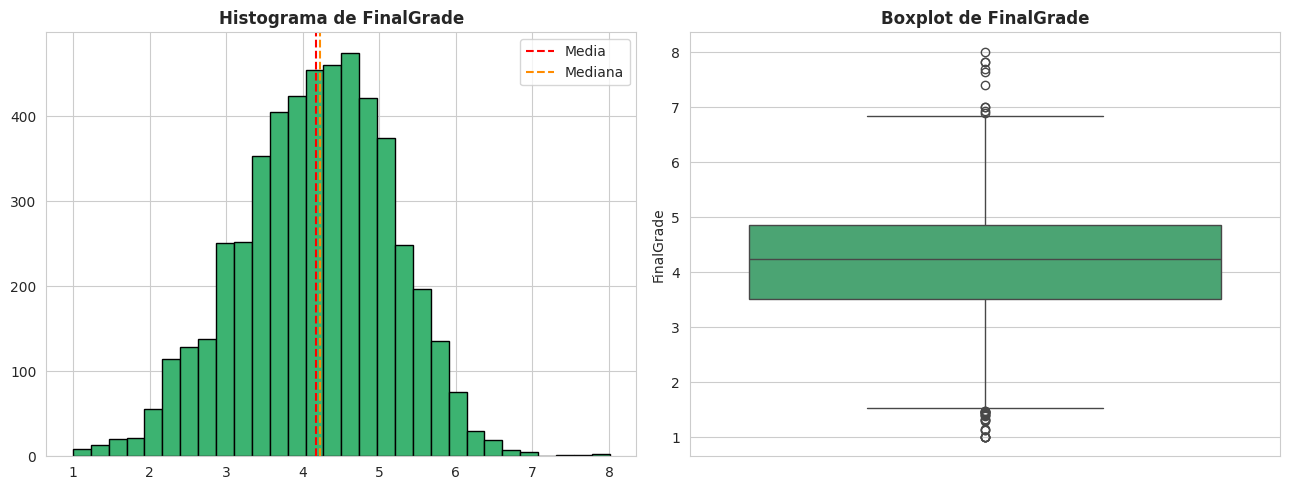

count    5096.000
mean        4.173
std         0.985
min         1.000
25%         3.510
50%         4.230
75%         4.863
max         8.007
Name: FinalGrade, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(data_eda["FinalGrade"], bins=30, color="mediumseagreen", edgecolor="black")
axes[0].axvline(data_eda["FinalGrade"].mean(), color="red", linestyle="--", label="Media")
axes[0].axvline(data_eda["FinalGrade"].median(), color="darkorange", linestyle="--", label="Mediana")
axes[0].set_title("Histograma de FinalGrade", fontsize=12, fontweight="bold")
axes[0].legend()

sns.boxplot(y=data_eda["FinalGrade"], ax=axes[1], color="mediumseagreen")
axes[1].set_title("Boxplot de FinalGrade", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print(data_eda["FinalGrade"].describe().round(3))

**Interpretación:** una vez excluidos los valores fuera de la escala 1.0–10.0, `FinalGrade` se distribuye
de forma aproximadamente simétrica en torno a una media cercana a **4.17** (mediana 4.23), sin sesgo
marcado hacia ninguno de los extremos de la escala. Existen algunos estudiantes con notas muy bajas o muy
altas (outliers estadísticos válidos, ver sección 2.5), pero la mayor concentración (rango intercuartílico)
está entre 3.51 y 4.86.

### 3.4 Relaciones entre variables (análisis bivariado / multivariado)

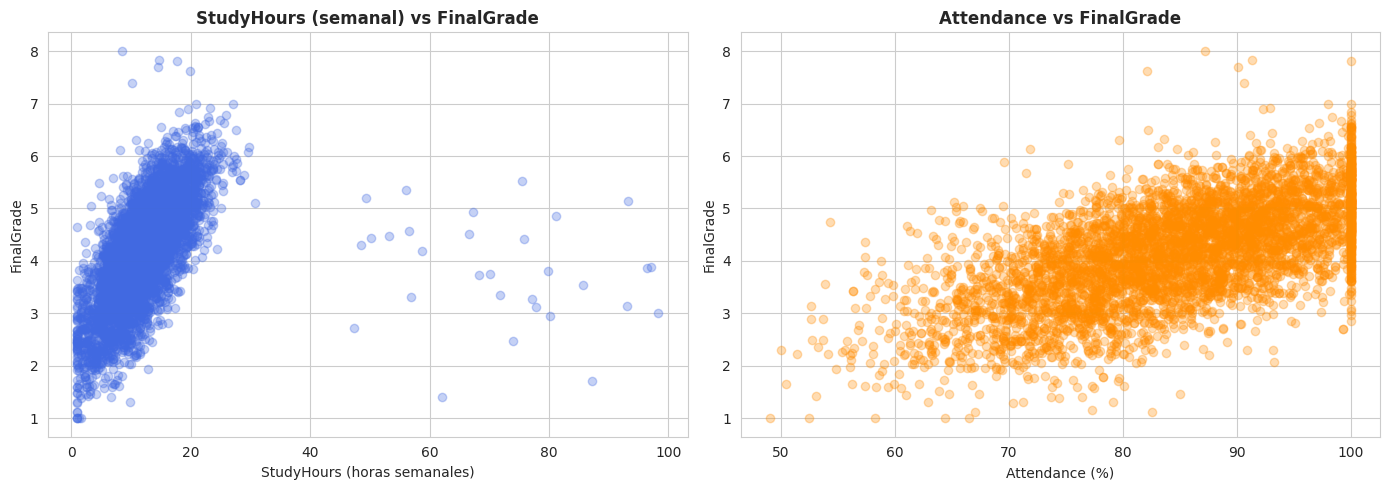

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(data_eda["StudyHours"], data_eda["FinalGrade"], alpha=0.3, color="royalblue")
axes[0].set_xlabel("StudyHours (horas semanales)")
axes[0].set_ylabel("FinalGrade")
axes[0].set_title("StudyHours (semanal) vs FinalGrade", fontsize=12, fontweight="bold")

axes[1].scatter(data_eda["Attendance"], data_eda["FinalGrade"], alpha=0.3, color="darkorange")
axes[1].set_xlabel("Attendance (%)")
axes[1].set_ylabel("FinalGrade")
axes[1].set_title("Attendance vs FinalGrade", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

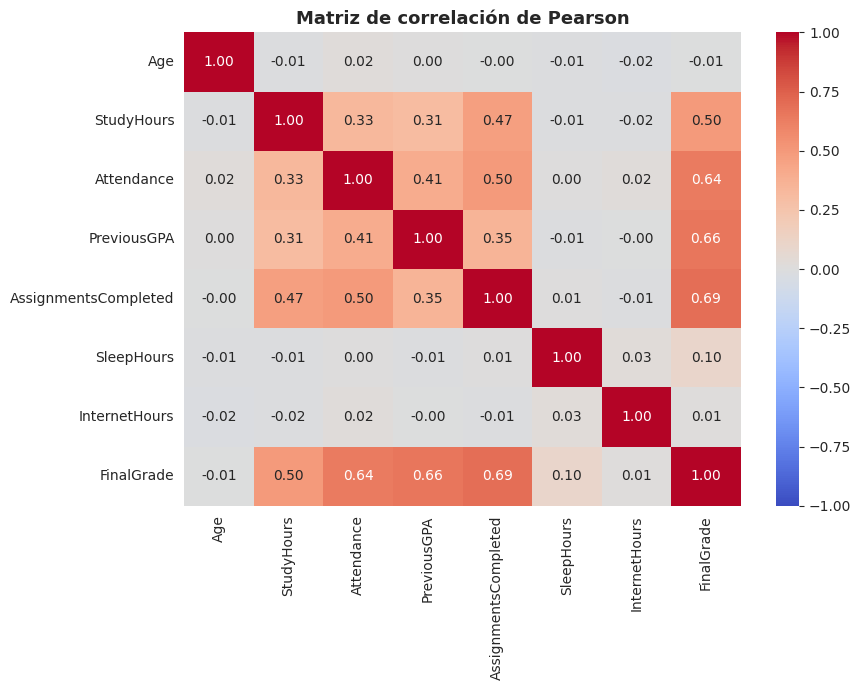

In [17]:
matriz_correlacion = data_eda[variables_numericas + ["FinalGrade"]].corr(method="pearson")

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación de Pearson", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretación:** `AssignmentsCompleted` (r ≈ 0.69), `PreviousGPA` (r ≈ 0.66) y `Attendance` (r ≈ 0.64) son
las variables numéricas con mayor correlación positiva con `FinalGrade`. `StudyHours` (horas **semanales** de
estudio, según `Metadata.md`) muestra una asociación positiva de intensidad moderada (r ≈ 0.50). `Age`,
`SleepHours` e `InternetHours` muestran correlaciones débiles o prácticamente nulas con la nota final. No se
observan señales fuertes de multicolinealidad severa entre las variables predictoras (correlaciones cruzadas
bajas), por lo que no es necesario descartar variables por redundancia.

### 3.5 Preguntas de investigación

#### Pregunta 1 — ¿Diferencia de `FinalGrade` entre estudiantes con y sin beca?

In [18]:
resumen_beca = data_eda.groupby("Scholarship")["FinalGrade"].agg(["mean", "std", "count"]).round(3)
display(resumen_beca)

media_si = resumen_beca.loc["Sí", "mean"]
media_no = resumen_beca.loc["No", "mean"]
diferencia = media_si - media_no

t_stat, p_valor = stats.ttest_ind(
    data_eda.loc[data_eda["Scholarship"] == "Sí", "FinalGrade"],
    data_eda.loc[data_eda["Scholarship"] == "No", "FinalGrade"],
    equal_var=False,
)

print(f"Promedio FinalGrade (con beca) : {media_si:.3f}")
print(f"Promedio FinalGrade (sin beca) : {media_no:.3f}")
print(f"Diferencia (con - sin beca)    : {diferencia:.3f}")
print(f"Test t de Welch: t = {t_stat:.3f}, p-valor = {p_valor:.2e}")

,mean,std,count
Scholarship,,,
No,4.077,0.994,3379
Sí,4.372,0.927,1636


Promedio FinalGrade (con beca) : 4.372
Promedio FinalGrade (sin beca) : 4.077
Diferencia (con - sin beca)    : 0.295
Test t de Welch: t = 10.301, p-valor = 1.58e-24


**Respuesta:** sí existe una diferencia. Los estudiantes **con beca** presentan un promedio de `FinalGrade`
de **4.37**, frente a **4.08** de quienes no poseen beca — una diferencia de **~0.30 puntos** a favor del
grupo becado. El test t de Welch entrega un p-valor extremadamente bajo (`t = 10.30`, `p < 0.001`), por lo
que la diferencia es **estadísticamente significativa** y no se explica por azar muestral.

#### Pregunta 2 — ¿Qué programa académico tiene mayor promedio de `FinalGrade`?

In [19]:
promedio_por_programa = data_eda.groupby("Program")["FinalGrade"].mean().sort_values(ascending=False).round(3)
display(promedio_por_programa)

programa_max = promedio_por_programa.index[0]
programa_min = promedio_por_programa.index[-1]
diferencia_programas = promedio_por_programa.iloc[0] - promedio_por_programa.iloc[-1]

print(f"\nPrograma con mayor promedio: {programa_max} ({promedio_por_programa.iloc[0]:.3f})")
print(f"Programa con menor promedio: {programa_min} ({promedio_por_programa.iloc[-1]:.3f})")
print(f"Diferencia: {diferencia_programas:.3f}")

,FinalGrade
Program,
Ingeniería Informática,4.232
Administración,4.227
Ingeniería Industrial,4.201
Ingeniería Civil,4.111
Contador Auditor,4.051



Programa con mayor promedio: Ingeniería Informática (4.232)
Programa con menor promedio: Contador Auditor (4.051)
Diferencia: 0.181


**Respuesta:** `Ingeniería Informática` presenta el mayor promedio de `FinalGrade` (**4.23**), mientras que
`Contador Auditor` presenta el menor (**4.05**). La diferencia entre ambos es de **~0.18 puntos**, una brecha
bastante más pequeña que la observada por posesión de beca, lo que sugiere que el programa académico influye
menos en el rendimiento que otros factores (como la asistencia o las horas de estudio).

#### Pregunta 3 — ¿Relación entre `StudyHours` y `FinalGrade`?

In [20]:
datos_validos_p3 = data_eda.dropna(subset=["StudyHours", "FinalGrade"])
correlacion_study, p_valor_study = stats.pearsonr(datos_validos_p3["StudyHours"], datos_validos_p3["FinalGrade"])

print(f"Coeficiente de correlación de Pearson (StudyHours vs FinalGrade): {correlacion_study:.3f}")
print(f"p-valor: {p_valor_study:.2e}")

Coeficiente de correlación de Pearson (StudyHours vs FinalGrade): 0.496
p-valor: 2.97e-304


**Respuesta:** existe una relación **positiva y de intensidad moderada** entre `StudyHours` y `FinalGrade`
(r = **0.50**, p < 0.001): a mayor cantidad de horas de estudio semanales, mayor tiende a ser la nota final,
aunque la asociación es notoriamente más débil que la de `Attendance`, `PreviousGPA` o `AssignmentsCompleted`.
Este resultado es coherente con el que se obtiene sin ningún tratamiento sobre los datos crudos (r ≈ 0.49),
lo que confirma que `StudyHours` —al ser una variable semanal con límite físico de 168 horas
(`Metadata.md`)— no presenta valores fuera de su dominio real.

#### Pregunta 4 — ¿Relación entre `Attendance` y `FinalGrade`?

Coeficiente de correlación de Pearson (Attendance vs FinalGrade): 0.638
p-valor: 0.00e+00


/tmp/ipykernel_4639/1971976110.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_cuartiles = datos_validos_p4.groupby("Cuartil_Attendance")["FinalGrade"].mean().round(3)


,FinalGrade
Cuartil_Attendance,
Q1 (más baja),3.313
Q2,4.005
Q3,4.472
Q4 (más alta),4.939


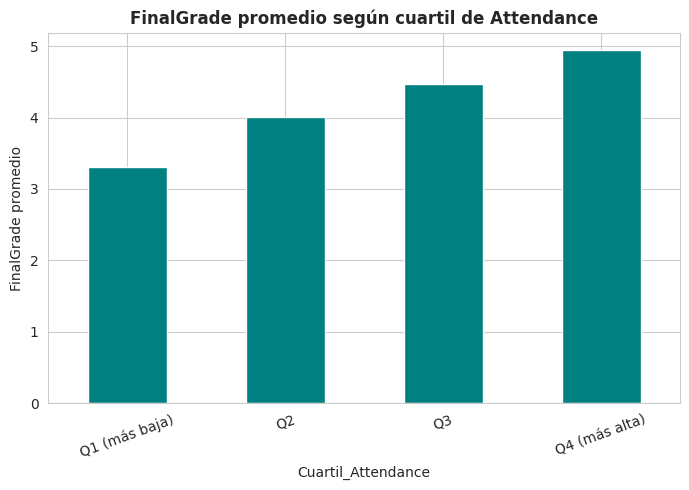

In [21]:
datos_validos_p4 = data_eda.dropna(subset=["Attendance", "FinalGrade"])
correlacion_asistencia, p_valor_asistencia = stats.pearsonr(datos_validos_p4["Attendance"], datos_validos_p4["FinalGrade"])

print(f"Coeficiente de correlación de Pearson (Attendance vs FinalGrade): {correlacion_asistencia:.3f}")
print(f"p-valor: {p_valor_asistencia:.2e}")

# Comparación por cuartiles de asistencia como evidencia complementaria
datos_validos_p4 = datos_validos_p4.copy()
datos_validos_p4["Cuartil_Attendance"] = pd.qcut(datos_validos_p4["Attendance"], 4,
                                                   labels=["Q1 (más baja)", "Q2", "Q3", "Q4 (más alta)"])
resumen_cuartiles = datos_validos_p4.groupby("Cuartil_Attendance")["FinalGrade"].mean().round(3)
display(resumen_cuartiles)

plt.figure(figsize=(7, 5))
resumen_cuartiles.plot(kind="bar", color="teal")
plt.title("FinalGrade promedio según cuartil de Attendance", fontsize=12, fontweight="bold")
plt.ylabel("FinalGrade promedio")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Respuesta:** sí. Existe una relación **positiva y fuerte** entre `Attendance` y `FinalGrade`
(r = **0.64**, p < 0.001). La evidencia gráfica confirma el patrón: el promedio de `FinalGrade` aumenta de
forma consistente y monotónica entre el cuartil de menor asistencia (Q1 ≈ 3.31) y el de mayor asistencia
(Q4 ≈ 4.94). En conjunto, ambas evidencias (correlación y comparación por cuartiles) sustentan que los
estudiantes con mayor asistencia tienden a presentar mejor rendimiento académico.

### 3.6 Conclusiones generales del EDA

1. **El cumplimiento de tareas, el rendimiento previo y la asistencia son los factores numéricos más
   asociados al rendimiento académico**: `AssignmentsCompleted` (r ≈ 0.69), `PreviousGPA` (r ≈ 0.66) y
   `Attendance` (r ≈ 0.64) muestran las correlaciones más fuertes con `FinalGrade`. `StudyHours` (horas
   **semanales** de estudio, según `Metadata.md`) presenta una asociación positiva pero más moderada
   (r ≈ 0.50); `Age`, `SleepHours` e `InternetHours` muestran correlaciones débiles o nulas.

2. **Poseer beca se asocia con un mejor rendimiento académico**: los estudiantes becados obtienen, en
   promedio, 0.30 puntos más en `FinalGrade` que quienes no tienen beca, diferencia confirmada como
   estadísticamente significativa (test t de Welch, p < 0.001). Esto podría reflejar tanto un efecto de la
   beca (menor presión económica, mayor dedicación) como un sesgo de selección (las becas suelen otorgarse,
   entre otros criterios, a mejores rendimientos previos).

3. **El programa académico explica poca variación en el rendimiento**: la diferencia entre el programa con
   mejor y peor promedio (`Ingeniería Informática` vs `Contador Auditor`) es de solo 0.18 puntos, muy inferior
   a la brecha observada por beca. Esto sugiere que el rendimiento académico depende más del comportamiento
   individual del estudiante (cumplimiento de tareas, asistencia, rendimiento previo) que de la carrera que
   cursa o de las horas de estudio semanales reportadas.

# 4. Tratamiento de los datos: resumen de decisiones

A partir del diagnóstico de las secciones 2 y 3, se definen las siguientes decisiones de tratamiento, que se
implementarán de forma reproducible mediante `Pipeline` y `ColumnTransformer` en la sección 5:

| Problema | Variable(s) | Decisión | Justificación |
|---|---|---|---|
| Registros duplicados exactos | Todas | Eliminar, `keep="first"` | Copias idénticas del mismo estudiante; no aportan información y generan riesgo de overfitting |
| Objetivo fuera de escala | `FinalGrade` | Eliminar esas filas (4 registros, 0.08%) | Es la variable objetivo; imputarla introduciría una fuga de información artificial |
| Valores fuera de rango físico | `Attendance`, `SleepHours`, `InternetHours` | Convertir a `NaN` y luego imputar | Son errores de captura (físicamente imposibles), no información real que deba preservarse tal cual. `StudyHours` se verifica contra su dominio semanal `[0,168]` pero no presenta violaciones |
| Valores faltantes (nulos originales + inválidos convertidos a NaN) | Todas las variables numéricas | Imputar con la **mediana** | Menos del 5% de nulos por variable; la mediana es robusta a los outliers detectados |
| Valores faltantes | `Scholarship`, `Program` | Imputar con la **moda** | Estrategia estándar para variables categóricas nominales |
| Formato inconsistente | `Scholarship`, `Program` | Normalizar texto (minúsculas, sin tildes/espacios) y mapear a categorías canónicas | Evita que una misma categoría se cuente como varias distintas al codificar |
| Outliers estadísticos genuinos (dentro del rango de dominio válido) | Variables numéricas predictoras | **Capar (winsorizar)** a los límites IQR (Q1 - 1.5·IQR, Q3 + 1.5·IQR) | Reduce la influencia de valores extremos sin eliminar al estudiante ni su información en otras variables (evita excluir sistemáticamente perfiles minoritarios, como estudiantes de mayor edad) |
| Variables categóricas | `Scholarship`, `Program` | Codificación One-Hot | Son variables nominales sin orden; permite su uso en modelos lineales y basados en distancia |
| Variables numéricas | Todas las predictoras | Escalado estándar (`StandardScaler`) | Homogeniza la escala de variables con rangos muy distintos (p. ej. `Age` en años vs `Attendance` en %) |

**Nota importante:** el capping de outliers y el escalado se aplican **solo a las variables predictoras**;
`FinalGrade` se mantiene siempre separada del proceso de transformación, ya que es la variable objetivo de
los posibles modelos predictivos y debe conservar su escala e interpretación original.

# 5. Implementación del tratamiento mediante Pipeline y ColumnTransformer

Se implementan tres transformadores personalizados, compatibles con la API de scikit-learn
(`BaseEstimator` + `TransformerMixin`), para encapsular las reglas de negocio definidas en la sección 4:

1. **`DomainRangeCleaner`**: convierte a `NaN` los valores que violan un rango físico de dominio conocido.
2. **`IQRCapper`**: aprende los límites de Winsorización (Q1 - 1.5·IQR, Q3 + 1.5·IQR) sobre los datos de
   ajuste y capa (clip) los valores que los exceden.
3. **`CategoricalNormalizer`**: normaliza texto (tildes, mayúsculas, espacios) y mapea variantes a un
   catálogo cerrado de categorías.

Todos ellos exponen `get_feature_names_out` para ser compatibles con `ColumnTransformer.get_feature_names_out()`.

In [22]:
class DomainRangeCleaner(BaseEstimator, TransformerMixin):
    """
    Invalida (convierte a NaN) los valores que se encuentran fuera de un rango
    físico/de dominio conocido para cada columna indicada.

    Parámetros
    ----------
    bounds: dict[str, tuple[float, float]]
        Diccionario {nombre_columna: (limite_inferior, limite_superior)} con los
        rangos válidos de cada variable.
    """

    def __init__(self, bounds: dict):
        self.bounds = bounds

    def fit(self, X: pd.DataFrame, y=None) -> "DomainRangeCleaner":
        """
        No requiere aprendizaje; se mantiene por compatibilidad con la API de sklearn.

        Parámetros
        ----------
        X: pd.DataFrame
            Datos de entrada.
        y: None
            No utilizado.

        Retorna
        -------
        DomainRangeCleaner
            La propia instancia ajustada.
        """
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Aplica la invalidación de valores fuera de rango.

        Parámetros
        ----------
        X: pd.DataFrame
            Datos a transformar.

        Retorna
        -------
        pd.DataFrame
            Copia de `X` con los valores fuera de rango reemplazados por `NaN`.
        """
        X = pd.DataFrame(X).copy()
        for columna, (minimo, maximo) in self.bounds.items():
            if columna in X.columns:
                mascara = (X[columna] < minimo) | (X[columna] > maximo)
                X.loc[mascara, columna] = np.nan
        return X

    def get_feature_names_out(self, input_features=None):
        """Retorna los nombres de columnas sin modificar (transformador 1 a 1)."""
        return np.asarray(input_features)


class IQRCapper(BaseEstimator, TransformerMixin):
    """
    Winsoriza (capa) valores atípicos numéricos según el método del Rango
    Intercuartílico (IQR), aprendiendo los límites únicamente de los datos de ajuste.

    Parámetros
    ----------
    factor: float
        Multiplicador del IQR utilizado para definir los límites (por defecto 1.5).
    """

    def __init__(self, factor: float = 1.5):
        self.factor = factor

    def fit(self, X: pd.DataFrame, y=None) -> "IQRCapper":
        """
        Calcula y almacena los límites inferior y superior por columna.

        Parámetros
        ----------
        X: pd.DataFrame
            Datos de ajuste (deben estar imputados, sin NaN).
        y: None
            No utilizado.

        Retorna
        -------
        IQRCapper
            La propia instancia, con el atributo `bounds_` calculado.
        """
        X = pd.DataFrame(X)
        self.bounds_ = {}
        for columna in X.columns:
            q1, q3 = X[columna].quantile(0.25), X[columna].quantile(0.75)
            iqr = q3 - q1
            self.bounds_[columna] = (q1 - self.factor * iqr, q3 + self.factor * iqr)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Capa los valores de cada columna a los límites aprendidos en `fit`.

        Parámetros
        ----------
        X: pd.DataFrame
            Datos a transformar.

        Retorna
        -------
        pd.DataFrame
            Copia de `X` con los valores atípicos capados a [límite_inferior, límite_superior].
        """
        X = pd.DataFrame(X).copy()
        for columna, (minimo, maximo) in self.bounds_.items():
            X[columna] = X[columna].clip(lower=minimo, upper=maximo)
        return X

    def get_feature_names_out(self, input_features=None):
        """Retorna los nombres de columnas sin modificar (transformador 1 a 1)."""
        return np.asarray(input_features)


class CategoricalNormalizer(BaseEstimator, TransformerMixin):
    """
    Normaliza variables categóricas de texto (espacios, mayúsculas, tildes) y
    mapea variantes a un catálogo cerrado de categorías canónicas.

    Parámetros
    ----------
    mapping: dict[str, dict[str, str]]
        Diccionario {nombre_columna: {valor_normalizado_en_minusculas: categoria_canonica}}.
    """

    def __init__(self, mapping: dict):
        self.mapping = mapping

    def fit(self, X: pd.DataFrame, y=None) -> "CategoricalNormalizer":
        """
        No requiere aprendizaje; se mantiene por compatibilidad con la API de sklearn.

        Parámetros
        ----------
        X: pd.DataFrame
            Datos de entrada.
        y: None
            No utilizado.

        Retorna
        -------
        CategoricalNormalizer
            La propia instancia ajustada.
        """
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Aplica la normalización de texto y el mapeo a categorías canónicas.

        Parámetros
        ----------
        X: pd.DataFrame
            Datos a transformar.

        Retorna
        -------
        pd.DataFrame
            Copia de `X` con las categorías normalizadas.
        """
        X = pd.DataFrame(X).copy()
        for columna in X.columns:
            if columna in self.mapping:
                X[columna] = X[columna].apply(self._normalizar_valor, mapa_columna=self.mapping[columna])
        return X

    @staticmethod
    def _normalizar_valor(valor, mapa_columna: dict) -> str:
        """
        Normaliza un valor individual de texto y lo mapea a su categoría canónica.

        Parámetros
        ----------
        valor: Any
            Valor original de la celda (puede ser NaN).
        mapa_columna: dict[str, str]
            Mapeo {clave_normalizada: categoria_canonica} para la columna correspondiente.

        Retorna
        -------
        str
            Categoría canónica, o `NaN` si el valor original era nulo.
        """
        if pd.isna(valor):
            return np.nan
        clave = str(valor).strip().lower()
        for original, reemplazo in [("í", "i"), ("á", "a"), ("ó", "o"), ("é", "e"), ("ú", "u")]:
            clave = clave.replace(original, reemplazo)
        return mapa_columna.get(clave, str(valor).strip())

    def get_feature_names_out(self, input_features=None):
        """Retorna los nombres de columnas sin modificar (transformador 1 a 1)."""
        return np.asarray(input_features)

## 5.1 Limpieza a nivel de registro (duplicados y objetivo inválido)

Antes de construir el `ColumnTransformer`, se aplican las dos decisiones que operan **a nivel de fila** y no
de columna: eliminar duplicados exactos y descartar los registros con `FinalGrade` fuera de escala.

In [23]:
def limpiar_registros(df: pd.DataFrame, columna_objetivo: str = "FinalGrade") -> pd.DataFrame:
    """
    Elimina duplicados exactos y registros con la variable objetivo fuera de su
    escala de dominio válida (1.0 a 10.0).

    Parámetros
    ----------
    df: pd.DataFrame
        Dataset original, sin tratar.
    columna_objetivo: str
        Nombre de la variable objetivo a validar.

    Retorna
    -------
    pd.DataFrame
        Dataset con duplicados y objetivo inválido eliminados, con índice reiniciado.
    """
    n_original = len(df)

    df_limpio = df.drop_duplicates(keep="first").copy()
    n_tras_duplicados = len(df_limpio)

    mascara_objetivo_valido = (df_limpio[columna_objetivo] >= 1.0) & (df_limpio[columna_objetivo] <= 10.0)
    df_limpio = df_limpio[mascara_objetivo_valido].reset_index(drop=True)
    n_final = len(df_limpio)

    print(f"Registros originales               : {n_original}")
    print(f"Registros tras eliminar duplicados  : {n_tras_duplicados} (-{n_original - n_tras_duplicados})")
    print(f"Registros tras filtrar objetivo     : {n_final} (-{n_tras_duplicados - n_final})")

    return df_limpio


data_filtrada = limpiar_registros(data_raw)

Registros originales               : 5100
Registros tras eliminar duplicados  : 5000 (-100)
Registros tras filtrar objetivo     : 4996 (-4)


## 5.2 Definición de features (`X`) y variable objetivo (`y`)

`FinalGrade` se separa del resto de las variables de entrada **antes** de aplicar cualquier transformación,
tal como exige el enunciado, para evitar fuga de información hacia las variables predictoras.

In [24]:
X = data_filtrada[variables_numericas + variables_categoricas].copy()
y = data_filtrada["FinalGrade"].copy()
ids = data_filtrada["StudentID"].copy()

print(f"X (features)  : {X.shape}")
print(f"y (objetivo)  : {y.shape}")

X (features)  : (4996, 9)
y (objetivo)  : (4996,)


## 5.3 Construcción del `ColumnTransformer` y del `Pipeline`

In [25]:
# Límites de dominio alineados con el diccionario de datos oficial (`Metadata.md`):
# `StudyHours` es semanal (máximo físico 168h), y `PreviousGPA` usa la escala oficial 1.0-10.0.
limites_dominio_features = {
    "Attendance": (0, 100),
    "SleepHours": (0, 24),
    "StudyHours": (0, 168),
    "InternetHours": (0, 24),
    "PreviousGPA": (1.0, 10.0),
}

mapa_scholarship = {"si": "Sí", "no": "No"}
mapa_program = {
    "ingenieria informatica": "Ingeniería Informática",
    "ingenieria industrial": "Ingeniería Industrial",
    "ingenieria civil": "Ingeniería Civil",
    "administracion": "Administración",
    "contador auditor": "Contador Auditor",
}
mapa_categoricas = {"Scholarship": mapa_scholarship, "Program": mapa_program}

# --- Sub-pipeline para variables numéricas ---
pipeline_numerico = Pipeline(steps=[
    ("dominio", DomainRangeCleaner(bounds=limites_dominio_features)),
    ("imputador", SimpleImputer(strategy="median")),
    ("capador_outliers", IQRCapper(factor=1.5)),
    ("escalador", StandardScaler()),
])

# --- Sub-pipeline para variables categóricas ---
pipeline_categorico = Pipeline(steps=[
    ("normalizador", CategoricalNormalizer(mapping=mapa_categoricas)),
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocesador = ColumnTransformer(transformers=[
    ("num", pipeline_numerico, variables_numericas),
    ("cat", pipeline_categorico, variables_categoricas),
])

preprocesador

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('dominio',
                                                  DomainRangeCleaner(bounds={'Attendance': (0,
                                                                                            100),
                                                                             'InternetHours': (0,
                                                                                               24),
                                                                             'PreviousGPA': (1.0,
                                                                                             10.0),
                                                                             'SleepHours': (0,
                                                                                            24),
                                                                             'StudyHours': (0,
                                                                                            168)})),
                                                 ('imputador',
                                                  SimpleImputer(strategy='median')),
                                                 ('capador_outliers',
                                                  IQRCapper()),
                                                 ('escalador',
                                                  StandardScaler())]),
                                 ['Age', 'StudyHours', 'Attendance...
                                                                                             'contador auditor': 'Contador '
                                                                                                                 'Auditor',
                                                                                             'ingenieria civil': 'Ingeniería '
                                                                                                                 'Civil',
                                                                                             'ingenieria industrial': 'Ingeniería '
                                                                                                                      'Industrial',
                                                                                             'ingenieria informatica': 'Ingeniería '
                                                                                                                       'Informática'},
                                                                                 'Scholarship': {'no': 'No',
                                                                                                 'si': 'Sí'}})),
                                                 ('imputador',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('codificador',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Scholarship', 'Program'])])

## 5.4 Ajuste y transformación

El proceso es completamente reproducible: basta con volver a ejecutar `limpiar_registros()` sobre el CSV
original y luego `preprocesador.fit_transform(X)` para obtener el mismo resultado.

In [26]:
X_procesado = preprocesador.fit_transform(X)
nombres_features = preprocesador.get_feature_names_out()

print(f"Forma de X procesado: {X_procesado.shape}")
print(f"Cantidad de columnas tras codificación One-Hot: {len(nombres_features)}")
print(nombres_features)

Forma de X procesado: (4996, 14)
Cantidad de columnas tras codificación One-Hot: 14
['num__Age' 'num__StudyHours' 'num__Attendance' 'num__PreviousGPA'
 'num__AssignmentsCompleted' 'num__SleepHours' 'num__InternetHours'
 'cat__Scholarship_No' 'cat__Scholarship_Sí' 'cat__Program_Administración'
 'cat__Program_Contador Auditor' 'cat__Program_Ingeniería Civil'
 'cat__Program_Ingeniería Industrial'
 'cat__Program_Ingeniería Informática']


In [27]:
X_procesado_df = pd.DataFrame(X_procesado, columns=nombres_features)
X_procesado_df.head()

,num__Age,num__StudyHours,num__Attendance,num__PreviousGPA,num__AssignmentsCompleted,num__SleepHours,num__InternetHours,cat__Scholarship_No,cat__Scholarship_Sí,cat__Program_Administración,cat__Program_Contador Auditor,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Industrial,cat__Program_Ingeniería Informática
0,-0.433473,-0.288750,-0.101641,0.525939,-1.168177,-0.604301,-0.588646,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.559705,-0.460282,1.465352,1.461656,-0.605170,-0.398441,0.523066,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.607633,0.268729,0.779114,0.498007,0.769144,-0.250222,0.016076,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.867909,1.767592,-0.299119,-0.870654,0.406077,-0.694879,-0.154956,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.954025,-1.193377,-1.440546,-1.219803,-1.525470,-0.579598,-0.677217,1.0,0.0,0.0,0.0,1.0,0.0,0.0


# 6. Dataset final y evidencia

## 6.1 Construcción del dataset tratado

Se reincorpora el identificador `StudentID` y la variable objetivo `FinalGrade` (ya validada en su escala,
sin transformar) al resultado del `Pipeline`, para dejar un dataset final completo y trazable.

In [28]:
data_tratada = X_procesado_df.copy()
data_tratada.insert(0, "StudentID", ids.values)
data_tratada["FinalGrade"] = y.values

print(f"Dataset final tratado: {data_tratada.shape[0]} registros, {data_tratada.shape[1]} variables.")
data_tratada.head()

Dataset final tratado: 4996 registros, 16 variables.


,StudentID,num__Age,num__StudyHours,num__Attendance,num__PreviousGPA,num__AssignmentsCompleted,num__SleepHours,num__InternetHours,cat__Scholarship_No,cat__Scholarship_Sí,cat__Program_Administración,cat__Program_Contador Auditor,cat__Program_Ingeniería Civil,cat__Program_Ingeniería Industrial,cat__Program_Ingeniería Informática,FinalGrade
0,STU-10522,-0.433473,-0.288750,-0.101641,0.525939,-1.168177,-0.604301,-0.588646,0.0,1.0,0.0,0.0,0.0,1.0,0.0,3.96
1,STU-10947,2.559705,-0.460282,1.465352,1.461656,-0.605170,-0.398441,0.523066,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.09
2,STU-11352,0.607633,0.268729,0.779114,0.498007,0.769144,-0.250222,0.016076,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.37
3,STU-12298,0.867909,1.767592,-0.299119,-0.870654,0.406077,-0.694879,-0.154956,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.02
4,STU-13527,-0.954025,-1.193377,-1.440546,-1.219803,-1.525470,-0.579598,-0.677217,1.0,0.0,0.0,0.0,1.0,0.0,0.0,3.24


## 6.2 Verificación de calidad del dataset tratado

In [29]:
nulos_finales = data_tratada.isnull().sum().sum()
duplicados_finales = data_tratada.drop(columns=["StudentID"]).duplicated().sum()

# Verificación de inconsistencias remanentes en el propio target ya filtrado
inconsistencias_finales = int(((data_tratada["FinalGrade"] < 1.0) | (data_tratada["FinalGrade"] > 10.0)).sum())

# Outliers remanentes: al estar escaladas (media 0, std 1) tras el capping,
# se verifica que ningún valor numérico supere en magnitud el límite teórico esperado
columnas_numericas_finales = [c for c in nombres_features if c.startswith("num__")]
limite_teorico = 5  # cualquier |z| > 5 sería sospechoso tras estandarizar datos ya capados
outliers_remanentes = int((data_tratada[columnas_numericas_finales].abs() > limite_teorico).sum().sum())

print(f"Valores faltantes totales        : {nulos_finales}")
print(f"Registros duplicados restantes   : {duplicados_finales}")
print(f"Inconsistencias de objetivo       : {inconsistencias_finales}")
print(f"Posibles outliers extremos remanentes (|z| > {limite_teorico}) : {outliers_remanentes}")

Valores faltantes totales        : 0
Registros duplicados restantes   : 0
Inconsistencias de objetivo       : 0
Posibles outliers extremos remanentes (|z| > 5) : 0


**Verificación:** el dataset tratado no presenta valores faltantes, registros duplicados, inconsistencias de
dominio ni outliers extremos remanentes, confirmando que las estrategias definidas en la sección 4 se
aplicaron correctamente.

## 6.3 Comparación entre el dataset original y el dataset tratado

In [30]:
comparacion = pd.DataFrame({
    "Indicador": [
        "Cantidad de registros",
        "Cantidad de variables",
        "Valores faltantes (total)",
        "Registros duplicados",
        "Inconsistencias (dominio numérico + formato categórico)",
        "Outliers tratados (capados por IQR)",
    ],
    "Dataset original": [
        data_raw.shape[0],
        data_raw.shape[1],
        int(data_raw.isnull().sum().sum()),
        int(data_raw.duplicated().sum()),
        sum(resumen_inconsistencias.values()),
        int(resumen_outliers["n_outliers"].sum()),
    ],
    "Dataset tratado": [
        data_tratada.shape[0],
        data_tratada.shape[1],
        int(nulos_finales),
        int(duplicados_finales),
        int(inconsistencias_finales),
        0,
    ],
})
comparacion

,Indicador,Dataset original,Dataset tratado
0,Cantidad de registros,5100,4996
1,Cantidad de variables,11,16
2,Valores faltantes (total),1335,0
3,Registros duplicados,100,0
4,Inconsistencias (dominio numérico + formato ca...,134,0
5,Outliers tratados (capados por IQR),393,0


In [31]:
print(comparacion.to_markdown(index=False))

| Indicador                                               |   Dataset original |   Dataset tratado |
|:--------------------------------------------------------|-------------------:|------------------:|
| Cantidad de registros                                   |               5100 |              4996 |
| Cantidad de variables                                   |                 11 |                16 |
| Valores faltantes (total)                               |               1335 |                 0 |
| Registros duplicados                                    |                100 |                 0 |
| Inconsistencias (dominio numérico + formato categórico) |                134 |                 0 |
| Outliers tratados (capados por IQR)                     |                393 |                 0 |


**Lectura de la tabla:** el dataset tratado tiene 104 registros menos que el original (100 duplicados
exactos + 4 registros con objetivo fuera de escala), y más variables debido a la codificación One-Hot de
`Scholarship` y `Program` (que expande dos columnas categóricas en 7 columnas binarias). Todos los
indicadores de calidad —nulos, duplicados, inconsistencias y outliers no capados— llegan a cero.

## 6.4 Exportación del dataset tratado

In [32]:
RUTA_SALIDA = "rendimiento_academico_limpio.csv"
data_tratada.to_csv(RUTA_SALIDA, index=False)

print(f"Archivo exportado exitosamente: {RUTA_SALIDA}")
print(f"Dimensiones finales: {data_tratada.shape[0]} filas x {data_tratada.shape[1]} columnas")

Archivo exportado exitosamente: rendimiento_academico_limpio.csv
Dimensiones finales: 4996 filas x 16 columnas


---

## Conclusión general

El dataset `rendimiento_academico_evaluacion.csv` presentaba problemas típicos de un dato de origen real:
valores faltantes moderados (<5% por variable), duplicados exactos (2%), inconsistencias de formato en
variables categóricas, violaciones de dominio físico (porcentajes y horas fuera de rango) y outliers
estadísticos genuinos. Cada uno de estos problemas fue diagnosticado, cuantificado y tratado con una
estrategia justificada y documentada, evitando tanto la eliminación mecánica de datos como la imputación
ciega del objetivo. El resultado es un dataset reproducible (`rendimiento_academico_limpio.csv`), apto para
ser utilizado en el desarrollo de modelos predictivos de rendimiento académico.